# 01 - Overview de seguridad por repositorio

## Introducción
Este notebook presenta una vista ejecutiva del pipeline **Miner → Analyzer → Visualizer**.
Su objetivo es verificar que los datos existen, fueron consolidados correctamente y que son interpretables para análisis posterior.

## Pregunta que responde
**¿Tenemos evidencia trazable y consistente desde los artefactos raw hasta el dataset consolidado `analysis.json`?**

### Cómo interpretar esta sección
- Primero se revisan fuentes raw generadas por Miner.
- Luego se valida `metadata.validation` para detectar faltantes o archivos inválidos.
- Finalmente se resumen métricas por repositorio y su distribución visual.

### Por qué importa en ciberseguridad
Sin trazabilidad de datos, cualquier priorización de riesgo puede ser discutible. Este overview asegura base empírica mínima antes de concluir sobre exposición real.


## Origen de datos del Miner y significado del consolidado

- **SBOM (Syft)**: inventario de componentes desde `data/results/sboms/*_sbom.json`.
- **Vulnerabilidades (Grype)**: hallazgos desde `data/results/vulns/*_vuln.json`.
- **SAST (CodeQL SARIF)**: issues estáticos desde `data/reports/*_codeql.sarif`.
- **CI/CD findings**: señales de workflows/automatización insegura en reportes complementarios.

`analysis.json` funciona como **dataset consolidado estable**: integra resultados por repositorio y habilita comparaciones transversales sin depender de leer múltiples formatos en cada análisis.

### Significado de `metadata.validation`
`metadata.validation` resume calidad de ingestión:
- `warnings`: situaciones no bloqueantes (por ejemplo, cobertura parcial).
- `invalid_files`: artefactos que no cumplieron formato esperado.

Interpretación práctica: una validación limpia aumenta confianza; advertencias no invalidan resultados, pero sí su alcance.

## Glosario breve
- **SBOM**: lista estructurada de componentes de software.
- **Syft**: herramienta para generar SBOM.
- **Grype**: escáner de vulnerabilidades sobre componentes detectados.
- **CodeQL**: análisis estático de código para detectar patrones de riesgo.
- **CI/CD finding**: hallazgo de seguridad en pipelines de integración/entrega.
- **CWE**: clasificación estandarizada de tipos de debilidad.
- **risk_score**: puntaje híbrido (Grype 60% + CodeQL 20% + CI/CD 20%) para priorizar riesgo relativo entre repositorios (rango 0-10).


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'results').exists():
            return candidate
    return Path.cwd()


root = find_project_root()
analysis_path = root / 'data' / 'results' / 'analysis.json'

if not analysis_path.exists():
    raise FileNotFoundError(f'No se encontró analysis.json en: {analysis_path}')

analysis = json.loads(analysis_path.read_text(encoding='utf-8'))
repos = analysis.get('repositories', []) or []
metadata = analysis.get('metadata', {}) or {}

metadata

{'generated_at': '2026-05-04T03:18:56.147048+00:00',
 'repos_analyzed': 6,
 'data_sources': ['sbom', 'grype', 'codeql', 'cicd'],
 'validation': {'warnings': [], 'invalid_files': []}}

## Evidencia mínima desde datos raw

Carga directa de archivos raw del Miner (SBOM, Grype, CodeQL SARIF y CI/CD) para validar estructura y nulos básicos, manteniendo `analysis.json` para la vista consolidada.


In [2]:
raw_rows = []
raw_patterns = {
    'sbom': root / 'data' / 'results' / 'sboms',
    'vuln': root / 'data' / 'results' / 'vulns',
    'codeql': root / 'data' / 'reports',
    'cicd': root / 'data' / 'reports',
}

for path in sorted(raw_patterns['sbom'].glob('*_sbom.json')):
    data = json.loads(path.read_text(encoding='utf-8'))
    artifacts = data.get('artifacts', []) if isinstance(data, dict) else []
    raw_rows.append({'source':'sbom','repo':path.name.replace('_sbom.json',''),'primary_len':len(artifacts),'null_primary':int(not isinstance(artifacts, list))})

for path in sorted(raw_patterns['vuln'].glob('*_vuln.json')):
    data = json.loads(path.read_text(encoding='utf-8'))
    matches = data.get('matches', []) if isinstance(data, dict) else []
    raw_rows.append({'source':'vuln','repo':path.name.replace('_vuln.json',''),'primary_len':len(matches),'null_primary':int(not isinstance(matches, list))})

for path in sorted(raw_patterns['codeql'].glob('*_codeql.sarif')):
    data = json.loads(path.read_text(encoding='utf-8'))
    runs = data.get('runs', []) if isinstance(data, dict) else []
    first = runs[0] if isinstance(runs, list) and runs else {}
    results = first.get('results', []) if isinstance(first, dict) else []
    raw_rows.append({'source':'codeql','repo':path.name.replace('_codeql.sarif',''),'primary_len':len(results),'null_primary':int(not isinstance(results, list))})

for path in sorted(raw_patterns['cicd'].glob('*_cicd.json')):
    data = json.loads(path.read_text(encoding='utf-8'))
    findings = data.get('findings', []) if isinstance(data, dict) else []
    raw_rows.append({'source':'cicd','repo':path.name.replace('_cicd.json',''),'primary_len':len(findings),'null_primary':int(not isinstance(findings, list))})

df_raw_evidence = pd.DataFrame(raw_rows)
df_raw_evidence.groupby('source', as_index=False).agg(files=('repo','count'), total_primary=('primary_len','sum'), null_primary=('null_primary','sum'))


,source,files,total_primary,null_primary
0,cicd,6,4,0
1,codeql,3,24,0
2,sbom,6,6052,0
3,vuln,6,22,0


In [3]:
raw_sources = [
    {
        'source_type': 'sbom_syft',
        'path_pattern': 'data/results/sboms/*_sbom.json',
        'file_count': len(list((root / 'data' / 'results' / 'sboms').glob('*_sbom.json'))),
    },
    {
        'source_type': 'vuln_grype',
        'path_pattern': 'data/results/vulns/*_vuln.json',
        'file_count': len(list((root / 'data' / 'results' / 'vulns').glob('*_vuln.json'))),
    },
    {
        'source_type': 'codeql_sarif',
        'path_pattern': 'data/reports/*_codeql.sarif',
        'file_count': len(list((root / 'data' / 'reports').glob('*_codeql.sarif'))),
    },
    {
        'source_type': 'cicd_report',
        'path_pattern': 'data/reports/*_cicd.json',
        'file_count': len(list((root / 'data' / 'reports').glob('*_cicd.json'))),
    },
]

df_raw_inventory = pd.DataFrame(raw_sources)
df_raw_inventory

,source_type,path_pattern,file_count
0,sbom_syft,data/results/sboms/*_sbom.json,6
1,vuln_grype,data/results/vulns/*_vuln.json,6
2,codeql_sarif,data/reports/*_codeql.sarif,3
3,cicd_report,data/reports/*_cicd.json,6


In [4]:
validation = metadata.get('validation', {}) or {}
warnings = validation.get('warnings', []) or []
invalid_files = validation.get('invalid_files', []) or []

print('Resumen de validación:')
print(f"- warnings: {len(warnings)}")
print(f"- invalid_files: {len(invalid_files)}")

if warnings:
    print('\nWarnings:')
    for w in warnings:
        print(f'- {w}')

if invalid_files:
    print('\nArchivos inválidos:')
    for f in invalid_files:
        print(f'- {f}')

if not warnings and not invalid_files:
    print('\nSin advertencias ni archivos inválidos en metadata.validation.')

Resumen de validación:
- warnings: 0
- invalid_files: 0

Sin advertencias ni archivos inválidos en metadata.validation.


In [5]:
rows = []
for repo in repos:
    rows.append({
        'name': repo.get('name', 'unknown'),
        'components': repo.get('sbom', {}).get('total_components', 0),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
        'codeql_issues': repo.get('codeql', {}).get('total_issues', 0),
        'cicd_findings': repo.get('cicd', {}).get('total_findings', 0),
        'risk_score': repo.get('metrics', {}).get('risk_score', 0.0),
        'risk_score_raw': repo.get('metrics', {}).get('risk_score_raw', 0.0),
        'vulnerability_density': repo.get('metrics', {}).get('vulnerability_density', 0.0),
    })

df_repos = pd.DataFrame(rows)
if df_repos.empty:
    df_repos = pd.DataFrame(columns=[
        'name','components','vulnerabilities','codeql_issues','cicd_findings','risk_score','risk_score_raw','vulnerability_density'
    ])

df_repos = df_repos.sort_values('risk_score', ascending=False).reset_index(drop=True)
df_repos

,name,components,vulnerabilities,codeql_issues,cicd_findings,risk_score,risk_score_raw,vulnerability_density
0,langsmith-java,14,2,0,0,0.60,0.60,14.285714
1,deepagents,2276,10,11,2,0.01,0.01,0.439367
2,docs,502,5,0,0,0.00,0.00,0.996016
3,langchain,2330,1,13,2,0.00,0.00,0.042918
4,langsmith-go,31,0,0,0,0.00,0.00,0.000000
5,streaming-cookbook,899,4,0,0,0.00,0.00,0.444939


## Gráficos de distribución por repositorio

### Cómo interpretar esta sección
- **components**: tamaño del inventario analizado.
- **vulnerabilities**: volumen de exposición detectada por Grype.
- **codeql_issues**: señales de riesgo en código propio.
- **cicd_findings**: riesgos operativos en automatización.
- **risk_score_raw**: puntaje híbrido (Grype 60% + CodeQL 20% + CI/CD 20%) sin clampar.
- **risk_score**: versión clampada a máximo 10 para comparar repositorios.
- **vulnerability_density**: vulnerabilidades por 100 componentes (`total_vulnerabilities / max(total_components,1) * 100`).

### Por qué importa en ciberseguridad
Mirar solo totales puede sesgar decisiones. Estas métricas combinadas permiten distinguir entre repos grandes con riesgo distribuido y repos pequeños con concentración crítica.


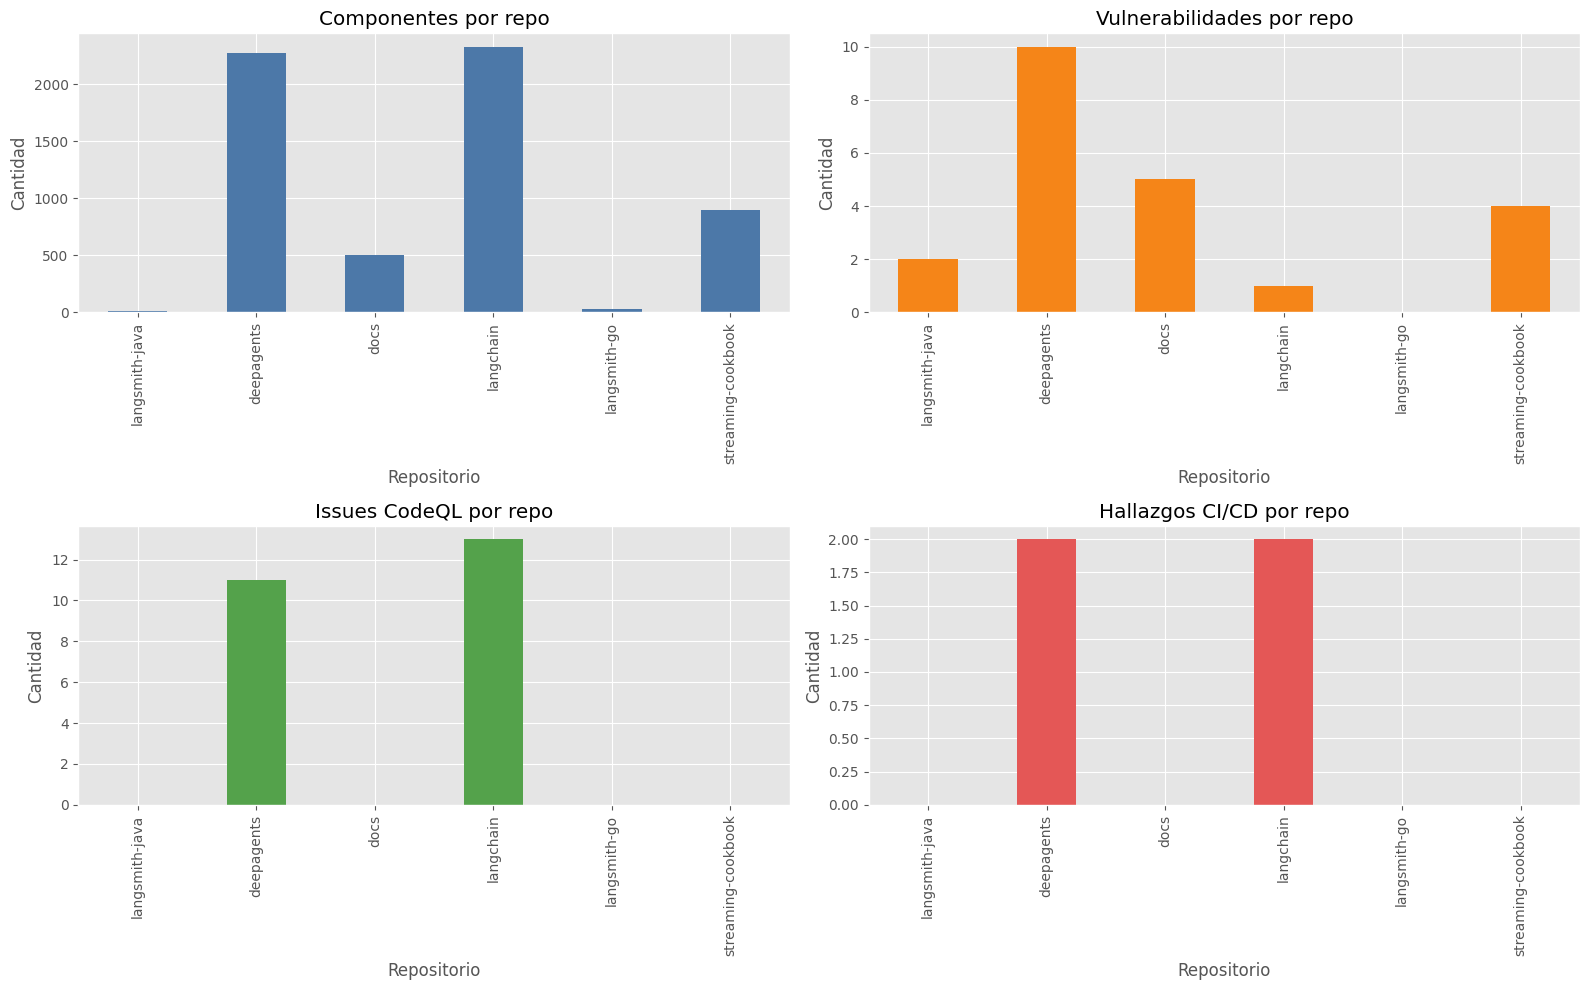

In [6]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if not df_repos.empty:
    df_repos.plot.bar(x='name', y='components', ax=axes[0, 0], legend=False, color='#4C78A8')
    df_repos.plot.bar(x='name', y='vulnerabilities', ax=axes[0, 1], legend=False, color='#F58518')
    df_repos.plot.bar(x='name', y='codeql_issues', ax=axes[1, 0], legend=False, color='#54A24B')
    df_repos.plot.bar(x='name', y='cicd_findings', ax=axes[1, 1], legend=False, color='#E45756')
else:
    for ax in axes.ravel():
        ax.text(0.5, 0.5, 'Sin datos de repositorio', ha='center', va='center')

axes[0, 0].set_title('Componentes por repo')
axes[0, 1].set_title('Vulnerabilidades por repo')
axes[1, 0].set_title('Issues CodeQL por repo')
axes[1, 1].set_title('Hallazgos CI/CD por repo')

for ax in axes.ravel():
    ax.set_xlabel('Repositorio')
    ax.set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

## Conclusión parcial
Este notebook permite verificar que los datos raw existen, que el dataset consolidado fue generado correctamente y que existe trazabilidad entre los resultados del Miner y el análisis posterior.